In [6]:
df = pd.read_excel(r"D:\C drive files\Downloads\Lab Session Data (1) (1).xlsx", sheet_name=0)

print("Shape:", df.shape)
print("\nAll columns:")
for i, c in enumerate(df.columns):
    print(f"  [{i}] {repr(c)}  | dtype={df[c].dtype} | NaN={df[c].isnull().sum()} | unique={df[c].nunique(dropna=True)}")

print("\nFull first 5 rows (transposed view):")
print(df.head().T)

Shape: (10, 22)

All columns:
  [0] 'Customer'  | dtype=str | NaN=0 | unique=10
  [1] 'Candies (#)'  | dtype=int64 | NaN=0 | unique=9
  [2] 'Mangoes (Kg)'  | dtype=int64 | NaN=0 | unique=5
  [3] 'Milk Packets (#)'  | dtype=int64 | NaN=0 | unique=4
  [4] 'Payment (Rs)'  | dtype=int64 | NaN=0 | unique=10
  [5] 'Unnamed: 5'  | dtype=float64 | NaN=10 | unique=0
  [6] 'Unnamed: 6'  | dtype=float64 | NaN=10 | unique=0
  [7] 'Unnamed: 7'  | dtype=float64 | NaN=10 | unique=0
  [8] 'Unnamed: 8'  | dtype=float64 | NaN=10 | unique=0
  [9] 'Unnamed: 9'  | dtype=float64 | NaN=10 | unique=0
  [10] 'Unnamed: 10'  | dtype=float64 | NaN=10 | unique=0
  [11] 'Unnamed: 11'  | dtype=float64 | NaN=10 | unique=0
  [12] 'Unnamed: 12'  | dtype=float64 | NaN=10 | unique=0
  [13] 'Unnamed: 13'  | dtype=float64 | NaN=10 | unique=0
  [14] 'Unnamed: 14'  | dtype=float64 | NaN=10 | unique=0
  [15] 'Unnamed: 15'  | dtype=float64 | NaN=10 | unique=0
  [16] 'Unnamed: 16'  | dtype=float64 | NaN=10 | unique=0
  [17] 'Un

In [8]:
def prepare_data(df, target_column=None):
    """Project-specific prep for Lab Session Data.xlsx."""
    # Drop the fully-empty Unnamed columns and scratch columns
    drop_cols = [c for c in df.columns if str(c).startswith('Unnamed')
                 or str(c) in ['Customer', 'Candy', 'Mango', 'Milk']]
    df = df.drop(columns=drop_cols, errors='ignore')

    print(f"After dropping irrelevant columns: {df.columns.tolist()}")

    # Derive the target: High Value if Payment >= 250
    if 'Payment (Rs)' in df.columns:
        THRESHOLD = 250
        df['HighValue'] = (df['Payment (Rs)'] >= THRESHOLD).astype(int)
        target_column = 'HighValue'
        print(f"Derived target 'HighValue' from Payment (Rs) >= {THRESHOLD}")
    else:
        raise ValueError("Expected 'Payment (Rs)' column not found.")

    y = df[target_column].values.astype(int)
    X_df = df.drop(columns=[target_column])

    # Keep numeric features
    X_df = X_df.select_dtypes(include=[np.number]).fillna(0)

    print(f"Features: {X_df.columns.tolist()}")
    print(f"Number of features: {X_df.shape[1]}")
    print(f"Classes: {np.unique(y)}  Counts: {dict(zip(*np.unique(y, return_counts=True)))}")

    scaler = StandardScaler()
    X = scaler.fit_transform(X_df.values)
    return X, y, target_column, X_df.columns.tolist()

In [9]:
TARGET_COLUMN = None   # will be set to 'HighValue' inside prepare_data

LAB 08 — PERCEPTRON & NEURAL NETWORKS

===== LOADING DATASET =====
Shape: (10, 22)
Columns: ['Customer', 'Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)', 'Payment (Rs)', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Candy', 'Mango', 'Milk']

Clean columns: ['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)', 'Payment (Rs)', 'HighValue']
Derived target from: Payment (Rs) >= 250
Features: ['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)', 'Payment (Rs)']
#features: 4
Classes: [0, 1]  Counts: {0: 4, 1: 6}

===== A2: Unit tests — Summation / Activation / Error =====
  summation_unit -> got=0.8000, expected=0.8000, match=True
  step           : [0, 0, 0, 1, 1]
  bipolar_step   : [-1, -1, 0, 1, 1]
  sigmoid        : [np.float64(0.1192), np.float64(0.3775), np.float64(0.5), np.float64(0.6225), np.float64(0.8808)]
  tanh           : [

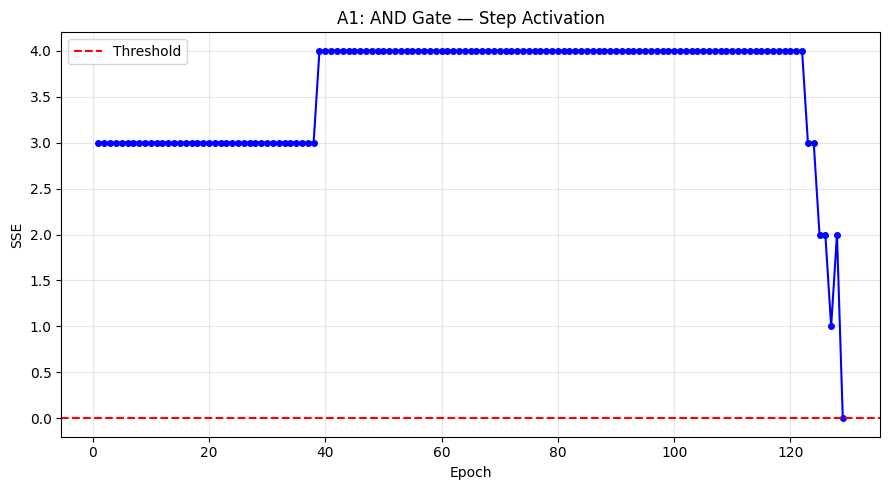

  Epochs: 129, SSE: 0.000000, Converged: True
  Final weights: [-0.1, 0.1, 0.05]
  Predictions: [0.0, 0.0, 0.0, 1.0]

===== A3: AND Gate — Activation Comparison =====


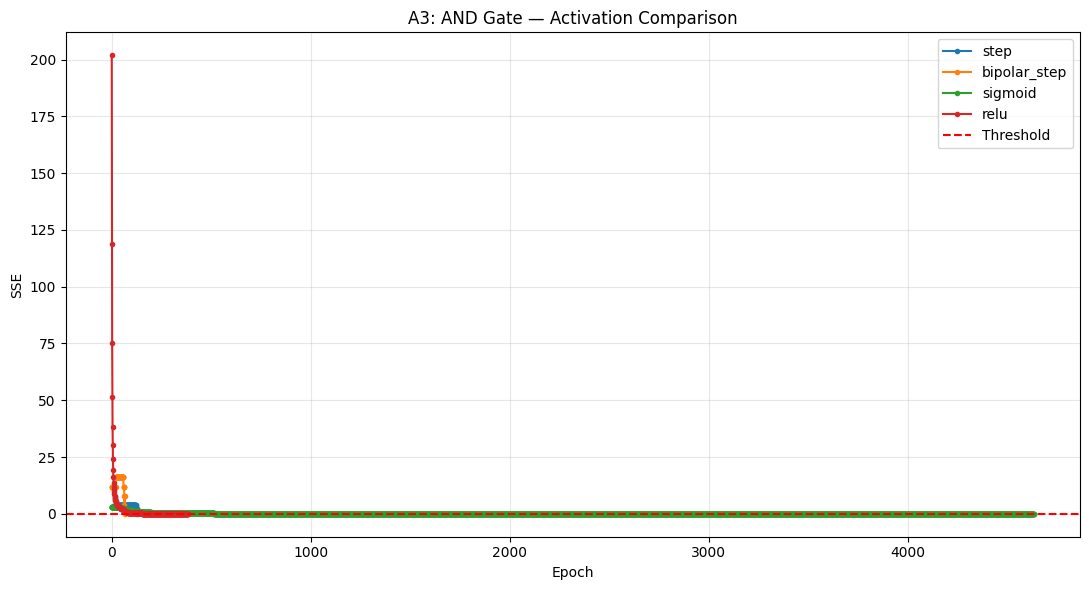

  step            | epochs=  129 | SSE=0.000000
  bipolar_step    | epochs=   67 | SSE=0.000000
  sigmoid         | epochs= 4634 | SSE=0.001999
  relu            | epochs=  383 | SSE=0.001992

===== A4: AND Gate — Varying Learning Rate =====


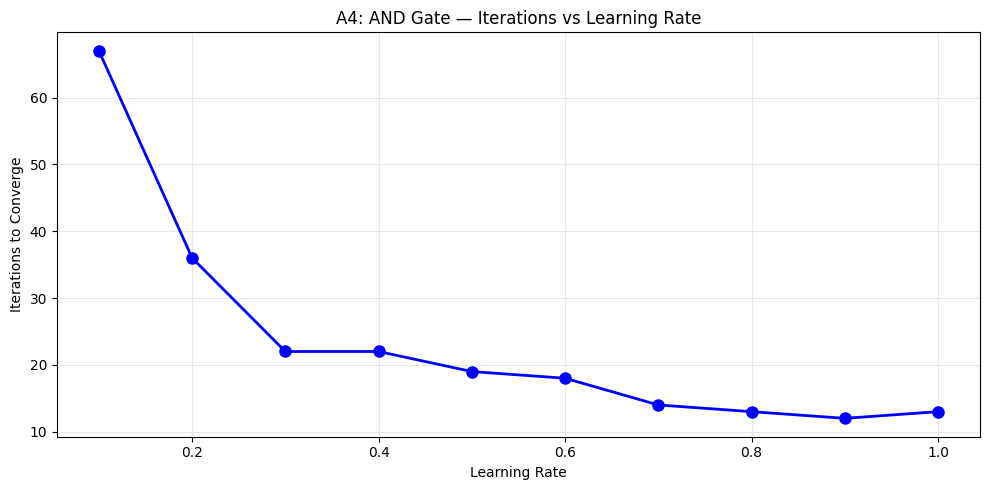

  LR=0.1 -> epochs=67
  LR=0.2 -> epochs=36
  LR=0.3 -> epochs=22
  LR=0.4 -> epochs=22
  LR=0.5 -> epochs=19
  LR=0.6 -> epochs=18
  LR=0.7 -> epochs=14
  LR=0.8 -> epochs=13
  LR=0.9 -> epochs=12
  LR=1.0 -> epochs=13

===== A5: XOR Gate — Repeat A1 & A3 + MLP =====


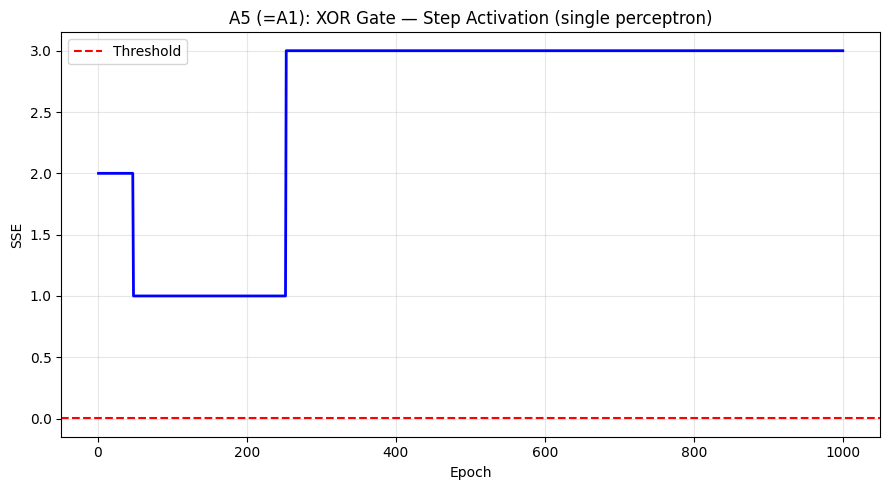

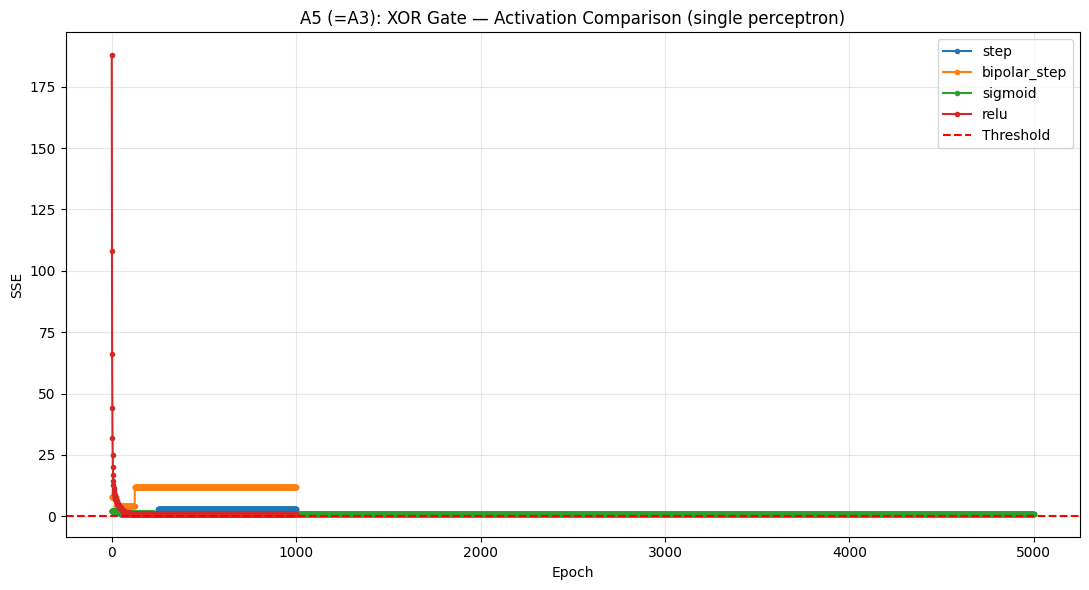

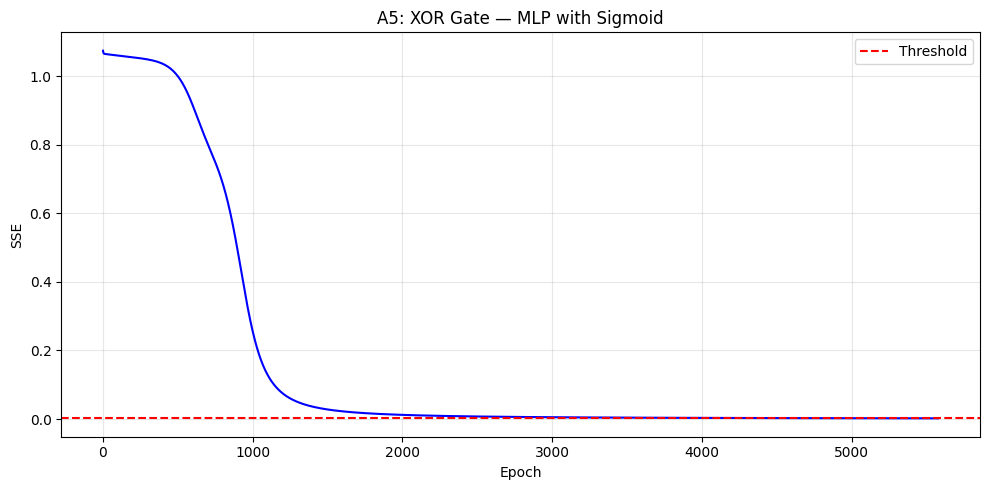

  Step (A1): epochs=1000, SSE=3.000000, converged=False
  -- Activation comparison (A3) --
    step            | epochs= 1000 | SSE=3.000000
    bipolar_step    | epochs= 1000 | SSE=12.000000
    sigmoid         | epochs= 5000 | SSE=1.000242
    relu            | epochs= 1000 | SSE=1.004155
  MLP: epochs=5577, SSE=0.002000, converged=True

===== A6: Project Data (Perceptron + Sigmoid) =====


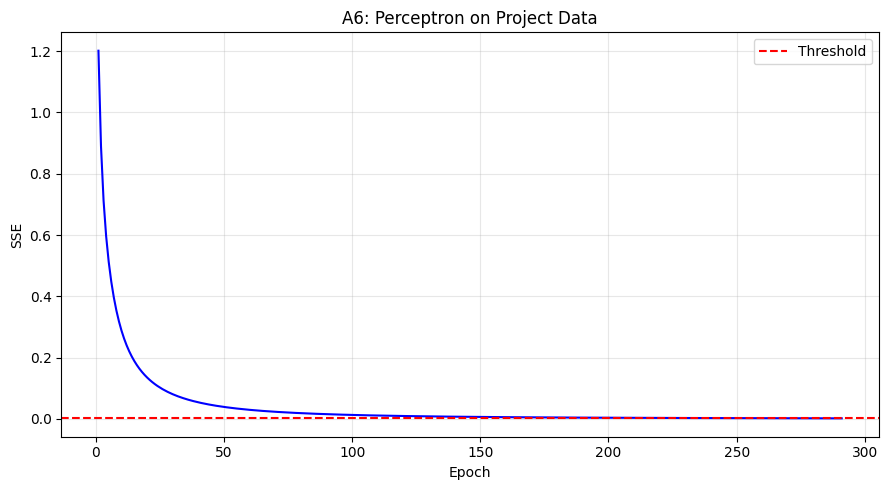

  n_samples=10, classes=[0, 1], counts=[4, 6]
  Epochs: 291, SSE: 0.001996, Converged: True
  Train accuracy: 100.00%
  Test accuracy:  100.00%

===== A7: Perceptron vs Pseudo-Inverse =====
  Pseudo-Inverse test accuracy: 66.67%
  Perceptron  test accuracy:    66.67% (epochs=113)

===== A8: Backprop MLP — AND Gate =====


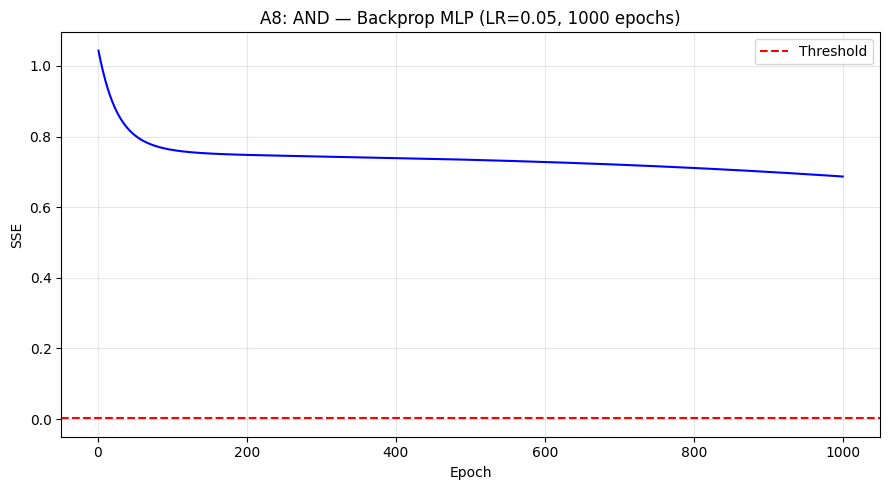

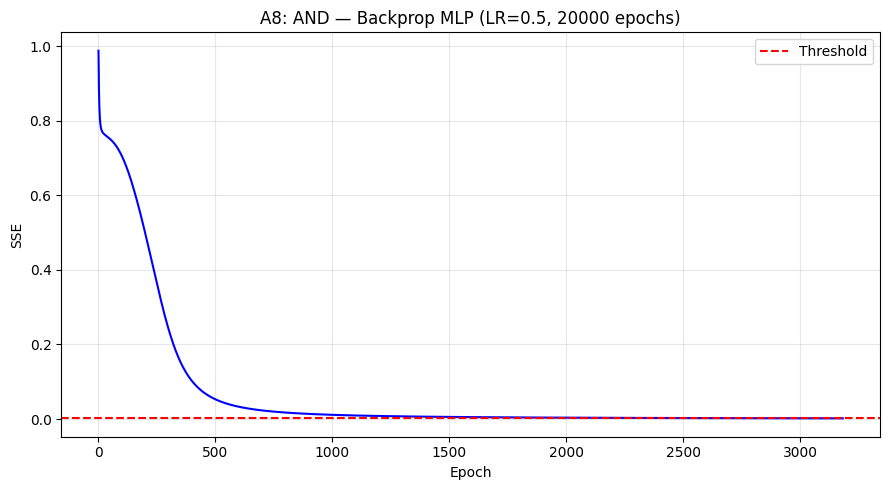

  -- Run 1: LR=0.05, max_epochs=1000 (as assigned) --
    Epochs: 1000, SSE: 0.686726, converged=False
    Preds: [0.2208, 0.2562, 0.2542, 0.2888]
  -- Run 2: LR=0.5, max_epochs=20000 (patched) --
    Epochs: 3183, SSE: 0.002000, converged=True
    Preds: [0.0008, 0.0197, 0.0197, 0.9651]

===== A9: Backprop MLP — XOR Gate =====


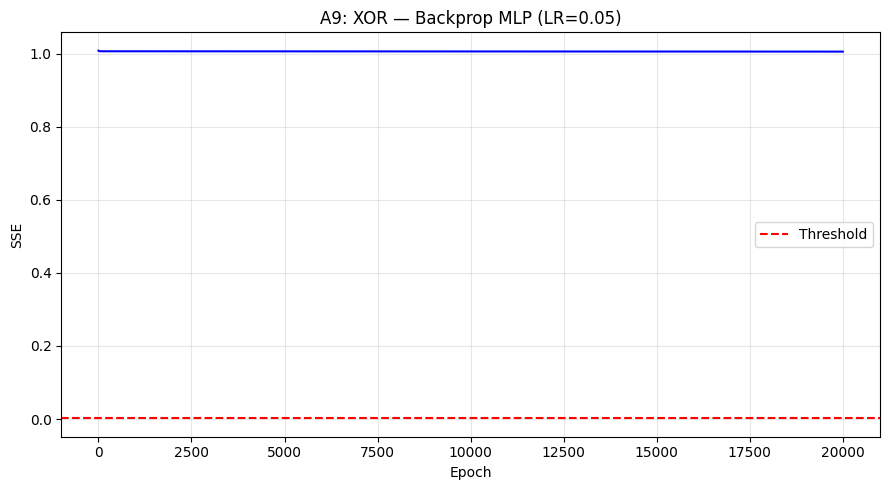

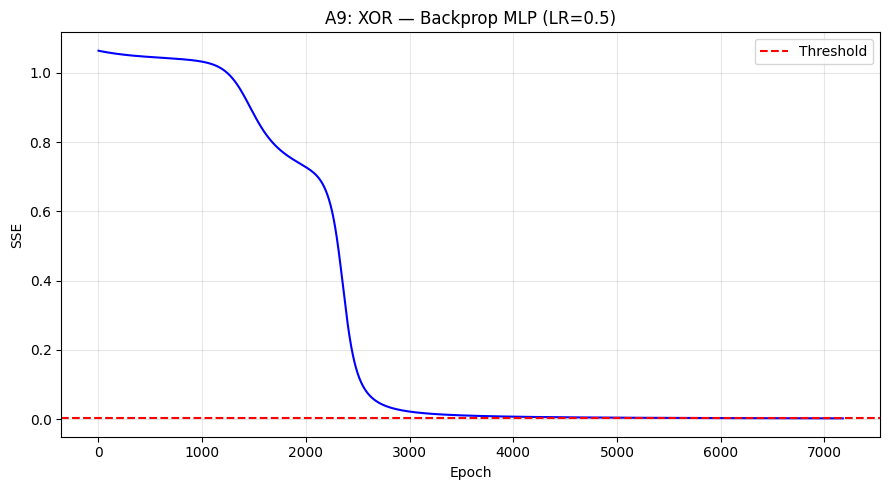

  lr_0.05: epochs=20000, SSE=1.005411, converged=False
    Preds: [0.4997, 0.5001, 0.4999, 0.5004]
  lr_0.5: epochs=7177, SSE=0.002000, converged=True
    Preds: [0.0163, 0.979, 0.979, 0.0292]

===== A10: AND Gate — 2 Output Nodes =====


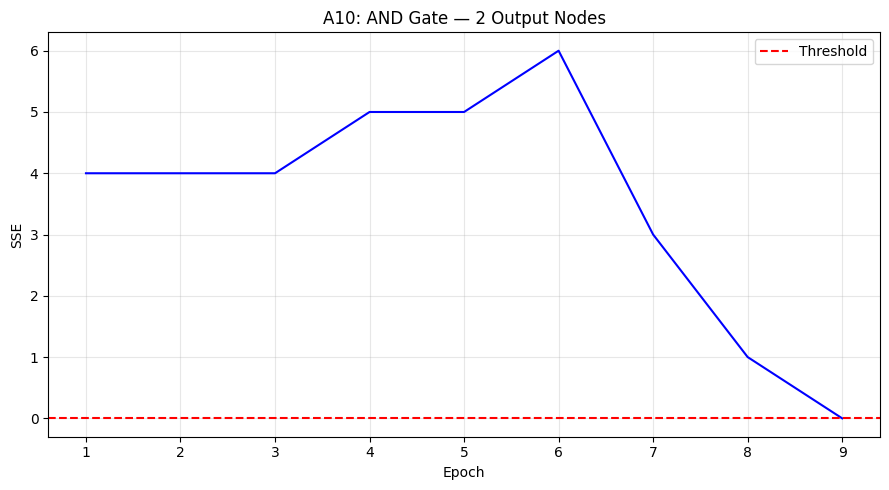

  Epochs: 9, SSE: 0.000000, Converged: True
  Predictions: [[1, 0], [1, 0], [1, 0], [0, 1]]

===== A11: MLPClassifier (AND & XOR) =====
  -- AND -- Iter: 74, Loss: 0.025503, Preds: [0, 0, 0, 1]
  -- XOR (lbfgs) -- Iter: 108, Loss: 0.008834, Preds: [0, 1, 1, 0]

===== A12: MLPClassifier on Project Data =====
  Iter: 60, Loss: 0.020492, Acc: 66.67%
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3


===== O1: LR vs Activations (Sigmoid vs ReLU) =====


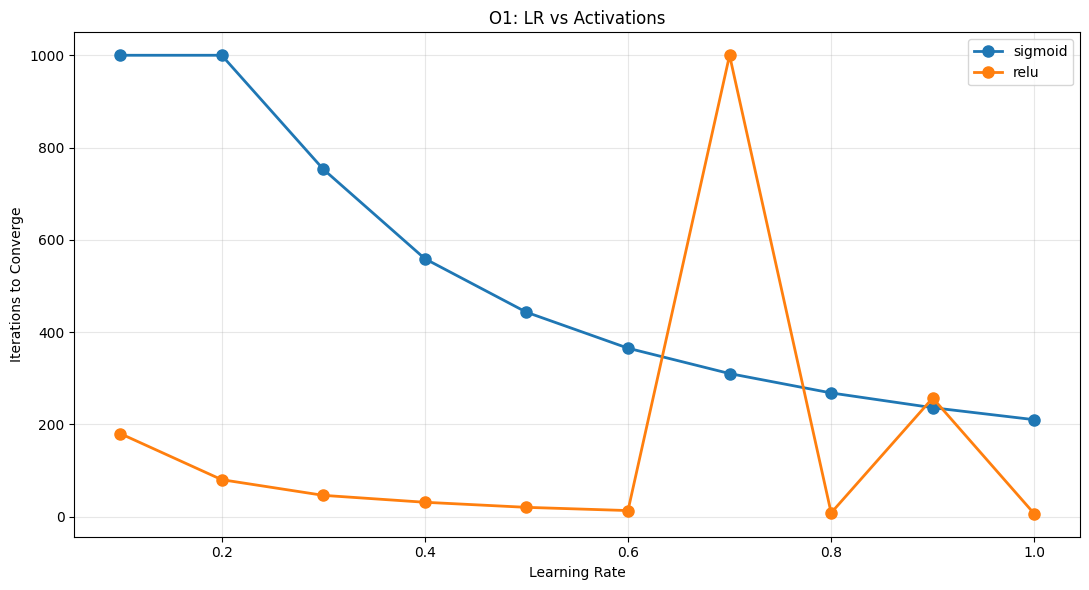

  sigmoid: [1000, 1000, 753, 559, 443, 365, 310, 268, 236, 210]
  relu: [180, 80, 46, 31, 20, 13, 1000, 8, 257, 6]

===== O2: LR vs Activations (TanH vs Leaky ReLU) =====


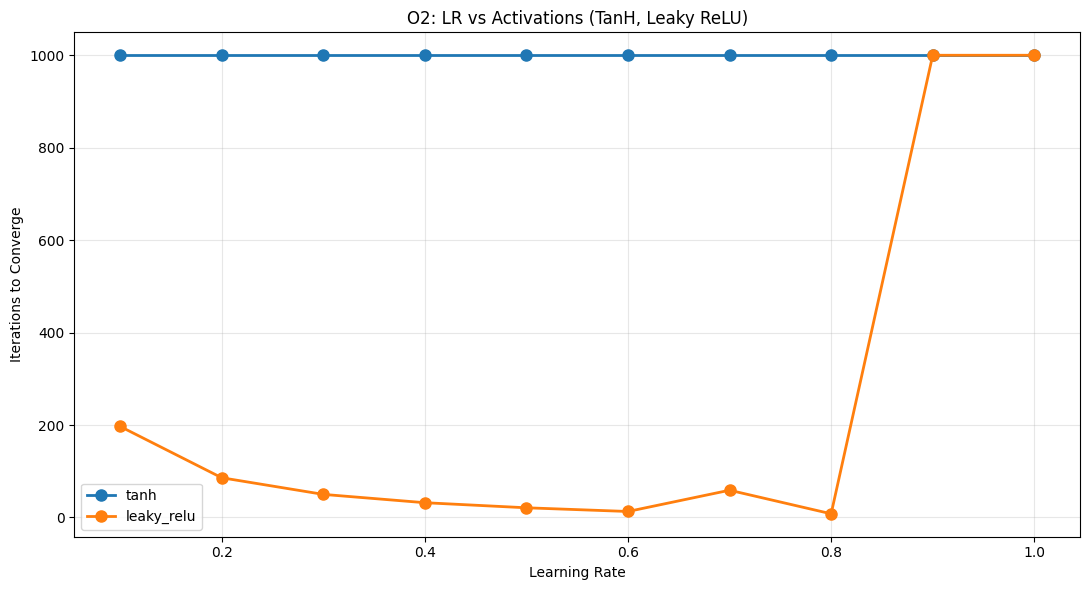

  tanh: [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]
  leaky_relu: [197, 86, 50, 32, 21, 13, 59, 8, 1000, 1000]


In [4]:
# =============================================================================
# LAB 08 - PERCEPTRON & NEURAL NETWORKS - REVISED (NO PRINT IN FUNCTIONS)
# Dataset: Lab Session Data (1) (1).xlsx
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

FILE_PATH = r"D:\C drive files\Downloads\Lab Session Data (1) (1).xlsx"
SHEET_NAME = 0
np.random.seed(42)
plt.close('all')


# =============================================================================
# MODULE 1 — SUMMATION UNIT
# =============================================================================
def summation_unit(inputs, weights):
    """Compute weighted sum (bias included as first weight)."""
    return float(np.dot(weights, inputs))


# =============================================================================
# MODULE 2 — ACTIVATION FUNCTIONS
# =============================================================================
def step_activation(y):
    """Step: 1 if y > 0 else 0."""
    return 1 if y > 0 else 0

def bipolar_step_activation(y):
    """Bipolar step: 1 if y > 0, -1 if y < 0, 0 if y == 0."""
    if y > 0:   return 1
    elif y < 0: return -1
    else:       return 0

def sigmoid_activation(y):
    """Sigmoid: 1 / (1 + exp(-y))."""
    y = np.clip(y, -500, 500)
    return 1.0 / (1.0 + np.exp(-y))

def tanh_activation(y):
    """Hyperbolic tangent."""
    return float(np.tanh(y))

def relu_activation(y):
    """ReLU: max(0, y)."""
    return max(0.0, float(y))

def leaky_relu_activation(y, alpha=0.01):
    """Leaky ReLU: y if y > 0, else alpha*y."""
    y = float(y)
    return y if y > 0 else alpha * y


# =============================================================================
# MODULE 3 — COMPARATOR UNIT (Error)
# =============================================================================
def calculate_error(targets, predictions):
    """Sum-Square-Error between targets and predictions."""
    t = np.array(targets, dtype=float)
    p = np.array(predictions, dtype=float)
    return float(np.sum((t - p) ** 2))


# =============================================================================
# PERCEPTRON CLASS (custom, no sklearn)
# =============================================================================
class Perceptron:
    def __init__(self, n_inputs, learning_rate=0.05, activation='step',
                 initial_weights=None, activation_alpha=0.01):
        self.n_inputs = n_inputs
        self.learning_rate = learning_rate
        self.activation_name = activation
        self.activation_alpha = activation_alpha
        if initial_weights is not None:
            self.weights = np.array(initial_weights, dtype=float)
        else:
            self.weights = np.random.uniform(-0.05, 0.05, n_inputs + 1)
        self._set_activation()

    def _set_activation(self):
        m = {'step': step_activation,
             'bipolar_step': bipolar_step_activation,
             'sigmoid': sigmoid_activation,
             'tanh': tanh_activation,
             'relu': relu_activation,
             'leaky_relu': lambda y: leaky_relu_activation(y, self.activation_alpha)}
        self.activation_function = m[self.activation_name]

    def predict(self, inputs):
        xb = np.insert(np.asarray(inputs, float), 0, 1)
        return float(self.activation_function(summation_unit(xb, self.weights)))

    def predict_batch(self, X):
        return np.array([self.predict(x) for x in X])

    def train(self, X, y, max_epochs=1000, convergence_threshold=0.002):
        X = np.array(X, float); y = np.array(y, float).ravel()
        errors = []
        converged = False
        epochs_run = 0
        for epoch in range(max_epochs):
            for i in range(len(X)):
                pred = self.predict(X[i])
                err = float(y[i] - pred)
                xb = np.insert(X[i], 0, 1)
                self.weights += self.learning_rate * err * xb
            sse = calculate_error(y, self.predict_batch(X))
            errors.append(sse)
            epochs_run = epoch + 1
            if sse <= convergence_threshold:
                converged = True
                break
        return {
            "epochs": epochs_run,
            "errors": errors,
            "final_sse": errors[-1],
            "converged": converged
        }


# =============================================================================
# DATA LOADING & PREPARATION (no prints)
# =============================================================================
def load_dataset(file_path, sheet_name):
    """Load the dataset and return the raw DataFrame."""
    return pd.read_excel(file_path, sheet_name=sheet_name)


def prepare_data(df):
    """Dataset-specific prep. Derives HighValue target from Payment."""
    drop_cols = [c for c in df.columns if str(c).startswith('Unnamed')
                 or str(c) in ['Customer', 'Candy', 'Mango', 'Milk']]
    df = df.drop(columns=drop_cols, errors='ignore')

    if 'Payment (Rs)' not in df.columns:
        raise ValueError("Payment (Rs) column missing.")

    THRESHOLD = 250
    df['HighValue'] = (df['Payment (Rs)'] >= THRESHOLD).astype(int)

    y = df['HighValue'].values.astype(int)
    X_df = df.drop(columns=['HighValue']).select_dtypes(include=[np.number]).fillna(0)

    X = StandardScaler().fit_transform(X_df.values)

    info = {
        "clean_columns": df.columns.tolist(),
        "target_derived_from": f"Payment (Rs) >= {THRESHOLD}",
        "feature_names": X_df.columns.tolist(),
        "num_features": X_df.shape[1],
        "classes": np.unique(y).tolist(),
        "class_counts": {int(k): int(v) for k, v in zip(*np.unique(y, return_counts=True))}
    }
    return X, y, 'HighValue', info


# =============================================================================
# A2 — UNIT TESTS (returns results dict)
# =============================================================================
def experiment_a2_units():
    """Unit tests for summation, activations, and error modules."""
    x = np.array([1.0, 0.5, -0.2])
    w = np.array([0.3, 0.8, -0.5])
    expected = 0.3*1.0 + 0.8*0.5 + (-0.5)*(-0.2)
    got = summation_unit(x, w)

    test_vals = [-2.0, -0.5, 0.0, 0.5, 2.0]

    t = np.array([0, 0, 0, 1])
    p = np.array([0.1, 0.2, 0.05, 0.9])
    expected_sse = float(np.sum((t - p)**2))
    got_sse = calculate_error(t, p)

    return {
        "summation": {"got": got, "expected": expected,
                      "match": bool(np.isclose(got, expected))},
        "activations": {
            "step":         [step_activation(v) for v in test_vals],
            "bipolar_step": [bipolar_step_activation(v) for v in test_vals],
            "sigmoid":      [round(sigmoid_activation(v), 4) for v in test_vals],
            "tanh":         [round(tanh_activation(v), 4) for v in test_vals],
            "relu":         [relu_activation(v) for v in test_vals],
            "leaky_relu":   [round(leaky_relu_activation(v), 4) for v in test_vals],
        },
        "error": {"got": got_sse, "expected": expected_sse,
                  "match": bool(np.isclose(got_sse, expected_sse))}
    }


# =============================================================================
# A1 — AND Gate with Step Activation (returns results, saves plot)
# =============================================================================
def experiment_a1():
    X = np.array([[0,0],[0,1],[1,0],[1,1]]); y = np.array([0,0,0,1])
    init_w = [10, 0.2, -0.75]
    p = Perceptron(2, learning_rate=0.05, activation='step', initial_weights=init_w)
    res = p.train(X, y, max_epochs=1000, convergence_threshold=0.002)

    plt.figure(figsize=(9,5))
    plt.plot(range(1, len(res['errors'])+1), res['errors'], 'b-o', ms=4)
    plt.axhline(0.002, color='r', ls='--', label='Threshold')
    plt.xlabel('Epoch'); plt.ylabel('SSE')
    plt.title('A1: AND Gate — Step Activation')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('a1_and_step.png', dpi=150); plt.show(); plt.close()

    return {
        "epochs": res['epochs'],
        "final_sse": res['final_sse'],
        "converged": res['converged'],
        "final_weights": p.weights.round(4).tolist(),
        "predictions": p.predict_batch(X).tolist()
    }


# =============================================================================
# A3 — Activation Comparison on AND Gate
# =============================================================================
def experiment_a3():
    X = np.array([[0,0],[0,1],[1,0],[1,1]])
    y = np.array([0,0,0,1])
    init_w = [10, 0.2, -0.75]
    acts = ['step','bipolar_step','sigmoid','relu']
    results = {}

    for a in acts:
        y_use = np.where(y == 0, -1, 1) if a == 'bipolar_step' else y
        max_ep = 5000 if a == 'sigmoid' else 1000
        p = Perceptron(2, learning_rate=0.05, activation=a, initial_weights=init_w)
        res = p.train(X, y_use, max_epochs=max_ep, convergence_threshold=0.002)
        results[a] = res

    plt.figure(figsize=(11,6))
    for a in acts:
        plt.plot(range(1, len(results[a]['errors'])+1), results[a]['errors'],
                 marker='o', ms=3, label=a)
    plt.axhline(0.002, color='r', ls='--', label='Threshold')
    plt.xlabel('Epoch'); plt.ylabel('SSE')
    plt.title('A3: AND Gate — Activation Comparison')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('a3_and_activations.png', dpi=150); plt.show(); plt.close()

    return {a: {"epochs": results[a]['epochs'],
                "sse": results[a]['final_sse']} for a in acts}


# =============================================================================
# A4 — Vary Learning Rate (AND Gate)
# =============================================================================
def experiment_a4():
    X = np.array([[0,0],[0,1],[1,0],[1,1]]); y = np.array([0,0,0,1])
    init_w = [10, 0.2, -0.75]
    lrs = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
    eps = []
    for lr in lrs:
        p = Perceptron(2, learning_rate=lr, activation='step', initial_weights=init_w)
        res = p.train(X, y, max_epochs=1000, convergence_threshold=0.002)
        eps.append(res['epochs'])

    plt.figure(figsize=(10,5))
    plt.plot(lrs, eps, 'b-o', ms=8, lw=2)
    plt.xlabel('Learning Rate'); plt.ylabel('Iterations to Converge')
    plt.title('A4: AND Gate — Iterations vs Learning Rate')
    plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('a4_and_lr.png', dpi=150); plt.show(); plt.close()

    return {lr: ep for lr, ep in zip(lrs, eps)}


# =============================================================================
# A5 — XOR Gate: repeat A1 + A3 + MLP
# =============================================================================
def _train_xor_mlp_manual(X, y, lr=0.5, hidden=4, max_epochs=20000, thresh=0.002):
    """Internal helper for the manual 2-layer MLP on XOR (no prints)."""
    np.random.seed(42)
    W1 = np.random.uniform(-0.5, 0.5, (hidden, 3))
    W2 = np.random.uniform(-0.5, 0.5, (1, hidden + 1))
    sig = lambda x: 1/(1+np.exp(-np.clip(x,-500,500)))
    dsig = lambda x: (lambda s: s*(1-s))(sig(x))
    errors, conv_ep = [], None
    for epoch in range(max_epochs):
        total = 0.0
        for i in range(len(X)):
            xb = np.insert(X[i], 0, 1)
            h_in = np.dot(W1, xb); h = sig(h_in)
            hb = np.insert(h, 0, 1)
            o_in = np.dot(W2, hb); o = float(sig(o_in)[0])
            err = float(y[i] - o); total += err**2
            d_o = err * float(dsig(o_in)[0])
            d_h = dsig(h_in) * (W2[0,1:] * d_o)
            W2 += lr * d_o * hb
            for j in range(hidden): W1[j] += lr * d_h[j] * xb
        errors.append(total)
        if total <= thresh:
            conv_ep = epoch + 1
            break
    return {"epochs": conv_ep if conv_ep else max_epochs,
            "errors": errors,
            "final_sse": errors[-1],
            "converged": conv_ep is not None}


def experiment_a5():
    X = np.array([[0,0],[0,1],[1,0],[1,1]])
    y = np.array([0,1,1,0])
    init_w = [10, 0.2, -0.75]
    acts = ['step','bipolar_step','sigmoid','relu']

    # --- A5 (=A1): single perceptron with Step ---
    p = Perceptron(2, learning_rate=0.05, activation='step', initial_weights=init_w)
    step_res = p.train(X, y, max_epochs=1000, convergence_threshold=0.002)

    plt.figure(figsize=(9,5))
    plt.plot(range(1, len(step_res['errors'])+1), step_res['errors'], 'b-', lw=2)
    plt.axhline(0.002, color='r', ls='--', label='Threshold')
    plt.xlabel('Epoch'); plt.ylabel('SSE')
    plt.title('A5 (=A1): XOR Gate — Step Activation (single perceptron)')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('a5_xor_step.png', dpi=150); plt.show(); plt.close()

    # --- A5 (=A3): all activations on XOR ---
    act_results = {}
    for a in acts:
        y_use = np.where(y == 0, -1, 1) if a == 'bipolar_step' else y
        max_ep = 5000 if a == 'sigmoid' else 1000
        p = Perceptron(2, learning_rate=0.05, activation=a, initial_weights=init_w)
        act_results[a] = p.train(X, y_use, max_epochs=max_ep, convergence_threshold=0.002)

    plt.figure(figsize=(11,6))
    for a in acts:
        plt.plot(range(1, len(act_results[a]['errors'])+1),
                 act_results[a]['errors'], marker='o', ms=3, label=a)
    plt.axhline(0.002, color='r', ls='--', label='Threshold')
    plt.xlabel('Epoch'); plt.ylabel('SSE')
    plt.title('A5 (=A3): XOR Gate — Activation Comparison (single perceptron)')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('a5_xor_activations.png', dpi=150); plt.show(); plt.close()

    # --- A5: manual 2-layer MLP ---
    mlp_res = _train_xor_mlp_manual(X, y)
    plt.figure(figsize=(10,5))
    plt.plot(range(1, len(mlp_res['errors'])+1), mlp_res['errors'], 'b-')
    plt.axhline(0.002, color='r', ls='--', label='Threshold')
    plt.xlabel('Epoch'); plt.ylabel('SSE')
    plt.title('A5: XOR Gate — MLP with Sigmoid')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('a5_xor_mlp.png', dpi=150); plt.show(); plt.close()

    return {
        "step_a1":   {"epochs": step_res['epochs'], "sse": step_res['final_sse'],
                      "converged": step_res['converged']},
        "activations": {a: {"epochs": act_results[a]['epochs'],
                            "sse": act_results[a]['final_sse']} for a in acts},
        "mlp":       {"epochs": mlp_res['epochs'], "sse": mlp_res['final_sse'],
                      "converged": mlp_res['converged']}
    }


# =============================================================================
# A6 — Project Data Classification (Perceptron + Sigmoid)
# =============================================================================
def experiment_a6(X, y):
    n = len(y)
    summary = {"n_samples": n,
               "classes": np.unique(y).tolist(),
               "counts": np.bincount(y).tolist()}
    if n < 10:
        summary["skipped"] = True
        return summary

    unique, counts = np.unique(y, return_counts=True)
    strat = y if (len(unique) == 2 and counts.min() >= 2) else None

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=strat)

    p = Perceptron(X_tr.shape[1], learning_rate=0.1, activation='sigmoid')
    res = p.train(X_tr, y_tr, max_epochs=1000, convergence_threshold=0.002)

    preds_tr = (p.predict_batch(X_tr) >= 0.5).astype(int).ravel()
    preds_te = (p.predict_batch(X_te) >= 0.5).astype(int).ravel()
    acc_tr = accuracy_score(y_tr.ravel(), preds_tr) * 100
    acc_te = accuracy_score(y_te.ravel(), preds_te) * 100

    plt.figure(figsize=(9,5))
    plt.plot(range(1, len(res['errors'])+1), res['errors'], 'b-')
    plt.axhline(0.002, color='r', ls='--', label='Threshold')
    plt.xlabel('Epoch'); plt.ylabel('SSE')
    plt.title('A6: Perceptron on Project Data')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('a6_customer.png', dpi=150); plt.show(); plt.close()

    summary.update({
        "epochs": res['epochs'],
        "final_sse": res['final_sse'],
        "converged": res['converged'],
        "train_acc": acc_tr,
        "test_acc": acc_te
    })
    return summary


# =============================================================================
# A7 — Perceptron vs Pseudo-Inverse
# =============================================================================
def experiment_a7(X, y):
    if len(y) < 10:
        return {"skipped": True}

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

    Xb = np.insert(X_tr, 0, 1, axis=1)
    w_pinv = np.dot(np.linalg.pinv(Xb), y_tr)
    Xteb = np.insert(X_te, 0, 1, axis=1)
    pinv_pred = (np.dot(Xteb, w_pinv) >= 0.5).astype(int).ravel()
    pinv_acc = accuracy_score(y_te.ravel(), pinv_pred) * 100

    p = Perceptron(X_tr.shape[1], learning_rate=0.1, activation='sigmoid')
    res = p.train(X_tr, y_tr, max_epochs=1000, convergence_threshold=0.002)
    perc_pred = (p.predict_batch(X_te) >= 0.5).astype(int).ravel()
    perc_acc = accuracy_score(y_te.ravel(), perc_pred) * 100

    return {"pinv_acc": pinv_acc, "perc_acc": perc_acc, "perc_epochs": res['epochs']}


# =============================================================================
# BACKPROP MLP CLASS
# =============================================================================
class BackpropMLP:
    def __init__(self, n_in, n_hid, n_out, lr=0.05):
        self.lr = lr
        self.W1 = np.random.uniform(-0.05, 0.05, (n_hid, n_in+1))
        self.W2 = np.random.uniform(-0.05, 0.05, (n_out, n_hid+1))

    def _sig(self, x):
        return 1/(1+np.exp(-np.clip(x,-500,500)))

    def _dsig(self, x):
        s = self._sig(x); return s*(1-s)

    def forward(self, x):
        xb = np.insert(x, 0, 1)
        self.h_in = np.dot(self.W1, xb); self.h_out = self._sig(self.h_in)
        hb = np.insert(self.h_out, 0, 1)
        self.o_in = np.dot(self.W2, hb); self.o_out = self._sig(self.o_in)
        return self.o_out

    def train(self, X, y, max_epochs=1000, thresh=0.002):
        errors, conv_ep = [], None
        for epoch in range(max_epochs):
            total = 0.0
            for i in range(len(X)):
                o = float(self.forward(X[i])[0])
                err = float(y[i] - o); total += err**2
                d_o = err * float(self._dsig(self.o_in)[0])
                hb = np.insert(self.h_out, 0, 1)
                d_h = self._dsig(self.h_in) * (self.W2[0,1:] * d_o)
                self.W2 += self.lr * d_o * hb
                xb = np.insert(X[i], 0, 1)
                for j in range(self.W1.shape[0]):
                    self.W1[j] += self.lr * d_h[j] * xb
            errors.append(total)
            if total <= thresh:
                conv_ep = epoch + 1
                break
        return {"epochs": conv_ep if conv_ep else max_epochs,
                "errors": errors,
                "final_sse": errors[-1],
                "converged": conv_ep is not None}


# =============================================================================
# A8 — Backprop MLP, AND Gate (two runs: assigned + patched)
# =============================================================================
def experiment_a8():
    X = np.array([[0,0],[0,1],[1,0],[1,1]]); y = np.array([0,0,0,1])

    # Run 1: as assigned (LR=0.05, max 1000)
    nn1 = BackpropMLP(2, 2, 1, lr=0.05)
    res1 = nn1.train(X, y, max_epochs=1000, thresh=0.002)
    preds1 = [float(nn1.forward(x)[0]) for x in X]

    plt.figure(figsize=(9,5))
    plt.plot(range(1, len(res1['errors'])+1), res1['errors'], 'b-')
    plt.axhline(0.002, color='r', ls='--', label='Threshold')
    plt.xlabel('Epoch'); plt.ylabel('SSE')
    plt.title('A8: AND — Backprop MLP (LR=0.05, 1000 epochs)')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('a8_and_bp_lr0.05.png', dpi=150); plt.show(); plt.close()

    # Run 2: patched (LR=0.5, max 20000)
    nn2 = BackpropMLP(2, 2, 1, lr=0.5)
    res2 = nn2.train(X, y, max_epochs=20000, thresh=0.002)
    preds2 = [float(nn2.forward(x)[0]) for x in X]

    plt.figure(figsize=(9,5))
    plt.plot(range(1, len(res2['errors'])+1), res2['errors'], 'b-')
    plt.axhline(0.002, color='r', ls='--', label='Threshold')
    plt.xlabel('Epoch'); plt.ylabel('SSE')
    plt.title('A8: AND — Backprop MLP (LR=0.5, 20000 epochs)')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('a8_and_bp_lr0.5.png', dpi=150); plt.show(); plt.close()

    return {
        "run1": {"epochs": res1['epochs'], "sse": res1['final_sse'],
                 "converged": res1['converged'], "preds": preds1},
        "run2": {"epochs": res2['epochs'], "sse": res2['final_sse'],
                 "converged": res2['converged'], "preds": preds2}
    }


# =============================================================================
# A9 — Backprop MLP, XOR Gate
# =============================================================================
def experiment_a9():
    X = np.array([[0,0],[0,1],[1,0],[1,1]]); y = np.array([0,1,1,0])
    out = {}
    for lr in [0.05, 0.5]:
        nn = BackpropMLP(2, 4, 1, lr=lr)
        res = nn.train(X, y, max_epochs=20000, thresh=0.002)
        preds = [float(nn.forward(x)[0]) for x in X]

        plt.figure(figsize=(9,5))
        plt.plot(range(1, len(res['errors'])+1), res['errors'], 'b-')
        plt.axhline(0.002, color='r', ls='--', label='Threshold')
        plt.xlabel('Epoch'); plt.ylabel('SSE')
        plt.title(f'A9: XOR — Backprop MLP (LR={lr})')
        plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
        plt.savefig(f'a9_xor_bp_lr{lr}.png', dpi=150); plt.show(); plt.close()

        out[f"lr_{lr}"] = {"epochs": res['epochs'], "sse": res['final_sse'],
                           "converged": res['converged'], "preds": preds}
    return out


# =============================================================================
# A10 — Two-Output-Node AND Gate
# =============================================================================
def experiment_a10():
    X = np.array([[0,0],[0,1],[1,0],[1,1]])
    Y = np.array([[1,0],[1,0],[1,0],[0,1]])
    np.random.seed(42)
    W = np.random.uniform(-0.5, 0.5, (2, 3))
    lr, errors, conv_ep = 0.1, [], None
    for epoch in range(5000):
        total = 0.0
        for i in range(len(X)):
            xb = np.insert(X[i], 0, 1)
            out = np.array([1 if v > 0 else 0 for v in np.dot(W, xb)])
            err = Y[i] - out
            total += float(np.sum(err**2))
            for j in range(2): W[j] += lr * err[j] * xb
        errors.append(total)
        if total <= 0.002:
            conv_ep = epoch + 1
            break

    final_preds = []
    for i in range(len(X)):
        xb = np.insert(X[i], 0, 1)
        out = np.array([1 if v > 0 else 0 for v in np.dot(W, xb)])
        final_preds.append(out.tolist())

    plt.figure(figsize=(9,5))
    plt.plot(range(1, len(errors)+1), errors, 'b-')
    plt.axhline(0.002, color='r', ls='--', label='Threshold')
    plt.xlabel('Epoch'); plt.ylabel('SSE')
    plt.title('A10: AND Gate — 2 Output Nodes')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('a10_and_2out.png', dpi=150); plt.show(); plt.close()

    return {"epochs": conv_ep if conv_ep else len(errors),
            "final_sse": errors[-1],
            "converged": conv_ep is not None,
            "predictions": final_preds}


# =============================================================================
# A11 — MLPClassifier for AND & XOR
# =============================================================================
def experiment_a11():
    X = np.array([[0,0],[0,1],[1,0],[1,1]])
    y_and = np.array([0,0,0,1]); y_xor = np.array([0,1,1,0])

    m1 = MLPClassifier(hidden_layer_sizes=(2,), activation='logistic',
                       learning_rate_init=0.1, max_iter=5000,
                       tol=0.002, random_state=42).fit(X, y_and)

    m2 = MLPClassifier(hidden_layer_sizes=(4,), activation='logistic',
                       solver='lbfgs', max_iter=20000,
                       tol=1e-6, random_state=42).fit(X, y_xor)

    return {
        "and": {"iter": m1.n_iter_, "loss": m1.loss_, "preds": m1.predict(X).tolist()},
        "xor": {"iter": m2.n_iter_, "loss": m2.loss_, "preds": m2.predict(X).tolist()}
    }


# =============================================================================
# A12 — MLPClassifier on Project Data
# =============================================================================
def experiment_a12(X, y):
    if len(y) < 10:
        return {"skipped": True}

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)
    m = MLPClassifier(hidden_layer_sizes=(8, 4), activation='logistic',
                      learning_rate_init=0.05, max_iter=2000,
                      tol=0.002, random_state=42)
    m.fit(X_tr, y_tr)
    y_pred = m.predict(X_te)
    acc = accuracy_score(y_te, y_pred) * 100
    report = classification_report(y_te, y_pred, zero_division=0)

    return {"iter": m.n_iter_, "loss": m.loss_, "acc": acc, "report": report}


# =============================================================================
# O1 — LR vs Activations (Sigmoid vs ReLU)
# =============================================================================
def experiment_o1():
    X = np.array([[0,0],[0,1],[1,0],[1,1]]); y = np.array([0,0,0,1])
    init_w = [10, 0.2, -0.75]
    lrs = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
    results = {}
    for a in ['sigmoid','relu']:
        results[a] = []
        for lr in lrs:
            p = Perceptron(2, learning_rate=lr, activation=a, initial_weights=init_w)
            res = p.train(X, y, max_epochs=1000, convergence_threshold=0.002)
            results[a].append(res['epochs'])

    plt.figure(figsize=(11,6))
    for a in ['sigmoid','relu']:
        plt.plot(lrs, results[a], 'o-', label=a, ms=8, lw=2)
    plt.xlabel('Learning Rate'); plt.ylabel('Iterations to Converge')
    plt.title('O1: LR vs Activations')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('o1_lr.png', dpi=150); plt.show(); plt.close()

    return {a: results[a] for a in results}


# =============================================================================
# O2 — Other Activations vs LR (TanH vs Leaky ReLU)
# =============================================================================
def experiment_o2():
    X = np.array([[0,0],[0,1],[1,0],[1,1]]); y = np.array([0,0,0,1])
    init_w = [10, 0.2, -0.75]
    lrs = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
    results = {}
    for a in ['tanh','leaky_relu']:
        results[a] = []
        for lr in lrs:
            p = Perceptron(2, learning_rate=lr, activation=a, initial_weights=init_w)
            res = p.train(X, y, max_epochs=1000, convergence_threshold=0.002)
            results[a].append(res['epochs'])

    plt.figure(figsize=(11,6))
    for a in ['tanh','leaky_relu']:
        plt.plot(lrs, results[a], 'o-', label=a, ms=8, lw=2)
    plt.xlabel('Learning Rate'); plt.ylabel('Iterations to Converge')
    plt.title('O2: LR vs Activations (TanH, Leaky ReLU)')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('o2_lr.png', dpi=150); plt.show(); plt.close()

    return {a: results[a] for a in results}


# =============================================================================
# DISPLAY HELPER — all printing happens here or in main
# =============================================================================
def display_results(results):
    """Print a nested dictionary of results in a readable, indented form."""
    def _fmt(v):
        if isinstance(v, float): return f"{v:.6f}"
        if isinstance(v, list):  return "[" + ", ".join(_fmt(x) for x in v) + "]"
        return str(v)

    def _walk(d, indent=0):
        pad = "  " * indent
        if isinstance(d, dict):
            for k, v in d.items():
                if isinstance(v, (dict, list)) and v and isinstance(v[0] if isinstance(v, list) else next(iter(v.values()), None), (dict, list)):
                    print(f"{pad}{k}:")
                    _walk(v, indent + 1)
                else:
                    print(f"{pad}{k}: {_fmt(v)}")
        elif isinstance(d, list):
            print(f"{pad}{_fmt(d)}")
        else:
            print(f"{pad}{_fmt(d)}")
    _walk(results)


# =============================================================================
# MAIN — all prints occur here
# =============================================================================
def main():
    print("LAB 08 — PERCEPTRON & NEURAL NETWORKS")

    # ---------- Load & Prepare ----------
    print("\n===== LOADING DATASET =====")
    X = y = None
    try:
        df = load_dataset(FILE_PATH, SHEET_NAME)
        print(f"Shape: {df.shape}")
        print(f"Columns: {df.columns.tolist()}")

        X, y, target_col, data_info = prepare_data(df)
        print(f"\nClean columns: {data_info['clean_columns']}")
        print(f"Derived target from: {data_info['target_derived_from']}")
        print(f"Features: {data_info['feature_names']}")
        print(f"#features: {data_info['num_features']}")
        print(f"Classes: {data_info['classes']}  Counts: {data_info['class_counts']}")
    except FileNotFoundError:
        print(f"[WARN] File not found: {FILE_PATH}")
    except Exception as e:
        print(f"[ERROR] {type(e).__name__}: {e}")

    # ---------- A2 ----------
    print("\n===== A2: Unit tests — Summation / Activation / Error =====")
    a2 = experiment_a2_units()
    print(f"  summation_unit -> got={a2['summation']['got']:.4f}, "
          f"expected={a2['summation']['expected']:.4f}, match={a2['summation']['match']}")
    for name, vals in a2['activations'].items():
        print(f"  {name:15s}: {vals}")
    print(f"  calculate_error -> got={a2['error']['got']:.6f}, "
          f"expected={a2['error']['expected']:.6f}, match={a2['error']['match']}")

    # ---------- A1 ----------
    print("\n===== A1: AND Gate — Step Activation =====")
    a1 = experiment_a1()
    print(f"  Epochs: {a1['epochs']}, SSE: {a1['final_sse']:.6f}, "
          f"Converged: {a1['converged']}")
    print(f"  Final weights: {a1['final_weights']}")
    print(f"  Predictions: {a1['predictions']}")

    # ---------- A3 ----------
    print("\n===== A3: AND Gate — Activation Comparison =====")
    a3 = experiment_a3()
    for name, r in a3.items():
        print(f"  {name:15s} | epochs={r['epochs']:5d} | SSE={r['sse']:.6f}")

    # ---------- A4 ----------
    print("\n===== A4: AND Gate — Varying Learning Rate =====")
    a4 = experiment_a4()
    for lr, ep in a4.items():
        print(f"  LR={lr:.1f} -> epochs={ep}")

    # ---------- A5 ----------
    print("\n===== A5: XOR Gate — Repeat A1 & A3 + MLP =====")
    a5 = experiment_a5()
    print(f"  Step (A1): epochs={a5['step_a1']['epochs']}, "
          f"SSE={a5['step_a1']['sse']:.6f}, converged={a5['step_a1']['converged']}")
    print("  -- Activation comparison (A3) --")
    for name, r in a5['activations'].items():
        print(f"    {name:15s} | epochs={r['epochs']:5d} | SSE={r['sse']:.6f}")
    print(f"  MLP: epochs={a5['mlp']['epochs']}, SSE={a5['mlp']['sse']:.6f}, "
          f"converged={a5['mlp']['converged']}")

    # ---------- A6 ----------
    if X is not None:
        print("\n===== A6: Project Data (Perceptron + Sigmoid) =====")
        a6 = experiment_a6(X, y)
        print(f"  n_samples={a6['n_samples']}, classes={a6['classes']}, "
              f"counts={a6['counts']}")
        if not a6.get('skipped'):
            print(f"  Epochs: {a6['epochs']}, SSE: {a6['final_sse']:.6f}, "
                  f"Converged: {a6['converged']}")
            print(f"  Train accuracy: {a6['train_acc']:.2f}%")
            print(f"  Test accuracy:  {a6['test_acc']:.2f}%")

    # ---------- A7 ----------
    if X is not None:
        print("\n===== A7: Perceptron vs Pseudo-Inverse =====")
        a7 = experiment_a7(X, y)
        if not a7.get('skipped'):
            print(f"  Pseudo-Inverse test accuracy: {a7['pinv_acc']:.2f}%")
            print(f"  Perceptron  test accuracy:    {a7['perc_acc']:.2f}% "
                  f"(epochs={a7['perc_epochs']})")

    # ---------- A8 ----------
    print("\n===== A8: Backprop MLP — AND Gate =====")
    a8 = experiment_a8()
    print(f"  -- Run 1: LR=0.05, max_epochs=1000 (as assigned) --")
    print(f"    Epochs: {a8['run1']['epochs']}, SSE: {a8['run1']['sse']:.6f}, "
          f"converged={a8['run1']['converged']}")
    print(f"    Preds: {[round(p,4) for p in a8['run1']['preds']]}")
    print(f"  -- Run 2: LR=0.5, max_epochs=20000 (patched) --")
    print(f"    Epochs: {a8['run2']['epochs']}, SSE: {a8['run2']['sse']:.6f}, "
          f"converged={a8['run2']['converged']}")
    print(f"    Preds: {[round(p,4) for p in a8['run2']['preds']]}")

    # ---------- A9 ----------
    print("\n===== A9: Backprop MLP — XOR Gate =====")
    a9 = experiment_a9()
    for key, r in a9.items():
        print(f"  {key}: epochs={r['epochs']}, SSE={r['sse']:.6f}, "
              f"converged={r['converged']}")
        print(f"    Preds: {[round(p,4) for p in r['preds']]}")

    # ---------- A10 ----------
    print("\n===== A10: AND Gate — 2 Output Nodes =====")
    a10 = experiment_a10()
    print(f"  Epochs: {a10['epochs']}, SSE: {a10['final_sse']:.6f}, "
          f"Converged: {a10['converged']}")
    print(f"  Predictions: {a10['predictions']}")

    # ---------- A11 ----------
    print("\n===== A11: MLPClassifier (AND & XOR) =====")
    a11 = experiment_a11()
    print(f"  -- AND -- Iter: {a11['and']['iter']}, Loss: {a11['and']['loss']:.6f}, "
          f"Preds: {a11['and']['preds']}")
    print(f"  -- XOR (lbfgs) -- Iter: {a11['xor']['iter']}, "
          f"Loss: {a11['xor']['loss']:.6f}, Preds: {a11['xor']['preds']}")

    # ---------- A12 ----------
    if X is not None:
        print("\n===== A12: MLPClassifier on Project Data =====")
        a12 = experiment_a12(X, y)
        if not a12.get('skipped'):
            print(f"  Iter: {a12['iter']}, Loss: {a12['loss']:.6f}, "
                  f"Acc: {a12['acc']:.2f}%")
            print(a12['report'])

    # ---------- O1 ----------
    print("\n===== O1: LR vs Activations (Sigmoid vs ReLU) =====")
    o1 = experiment_o1()
    for name, eps in o1.items():
        print(f"  {name}: {eps}")

    # ---------- O2 ----------
    print("\n===== O2: LR vs Activations (TanH vs Leaky ReLU) =====")
    o2 = experiment_o2()
    for name, eps in o2.items():
        print(f"  {name}: {eps}")


if __name__ == "__main__":
    main()